<a href="https://colab.research.google.com/github/lcn781/M12_REGRESSAO_I/blob/main/mod12_ex02.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Regressão 01 - tarefa 02 - transformações em X e Y

### 1. Melhorando o ajuste no percentual de gorjetas

a. Vamos partir do modelo feito na última tarefa, o que relaciona ```tip_pct``` e ```net_bill```. Carregue a base, os pacotes e reproduza este modelo aqui.

In [3]:
import pandas as pd
import seaborn as sns

import matplotlib.pyplot as plt

import numpy as np

import statsmodels.formula.api as smf

In [4]:
tips = sns.load_dataset("tips")
tips["tip_pct"] = tips['tip']/(tips['total_bill'] - tips['tip'])
tips['net_bill'] = tips['total_bill'] - tips['tip']
tips.head()


,total_bill,tip,sex,smoker,day,time,size,tip_pct,net_bill
0,16.99,1.01,Female,No,Sun,Dinner,2,0.063204,15.98
1,10.34,1.66,Male,No,Sun,Dinner,3,0.191244,8.68
2,21.01,3.50,Male,No,Sun,Dinner,3,0.199886,17.51
3,23.68,3.31,Male,No,Sun,Dinner,2,0.162494,20.37
4,24.59,3.61,Female,No,Sun,Dinner,4,0.172069,20.98


In [5]:
reg2 = smf.ols('tip_pct ~ net_bill', data = tips).fit()
reg2.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                tip_pct   R-squared:                       0.091
Model:                            OLS   Adj. R-squared:                  0.088
Method:                 Least Squares   F-statistic:                     24.31
Date:                Thu, 25 Jun 2026   Prob (F-statistic):           1.52e-06
Time:                        18:46:29   Log-Likelihood:                 108.00
No. Observations:                 244   AIC:                            -212.0
Df Residuals:                     242   BIC:                            -205.0
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      0.3053      0.023     13.166      0.000       0.260       0.351
net_bill      -0.0061      0.001     -4.931      0.000      -0.009      -0.004
==============================================================================
Omnibus:                      468.674   Durbin-Watson:                   1.987
Prob(Omnibus):                  0.000   Jarque-Bera (JB):           234437.604
Skew:                          11.104   Prob(JB):                         0.00
Kurtosis:                     153.221   Cond. No.                         43.3
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

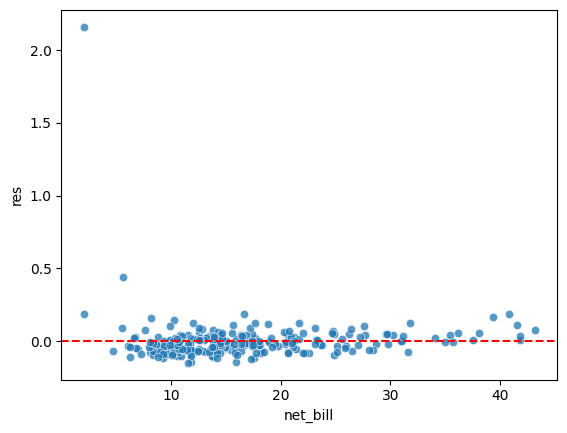

In [6]:
tips['res'] = reg2.resid
sns.scatterplot(x = 'net_bill', y = 'res', data = tips, alpha = .75)
plt.axhline(y = 0, color = 'red', linestyle='--')


### 2. ajuste o modelo de ```tip_pct``` em função do logaritmo de ```net_bill```.

In [7]:
reg_log_net_bill = smf.ols('tip_pct ~ np.log(net_bill)', data = tips).fit()
reg_log_net_bill.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                tip_pct   R-squared:                       0.202
Model:                            OLS   Adj. R-squared:                  0.198
Method:                 Least Squares   F-statistic:                     61.16
Date:                Thu, 25 Jun 2026   Prob (F-statistic):           1.62e-13
Time:                        18:47:06   Log-Likelihood:                 123.81
No. Observations:                 244   AIC:                            -243.6
Df Residuals:                     242   BIC:                            -236.6
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
====================================================================================
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
Intercept            0.6181      0.054     11.444      0.000       0.512       0.724
np.log(net_bill)    -0.1534      0.020     -7.820      0.000      -0.192      -0.115
==============================================================================
Omnibus:                      440.899   Durbin-Watson:                   1.965
Prob(Omnibus):                  0.000   Jarque-Bera (JB):           171509.052
Skew:                           9.850   Prob(JB):                         0.00
Kurtosis:                     131.381   Cond. No.                         17.9
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

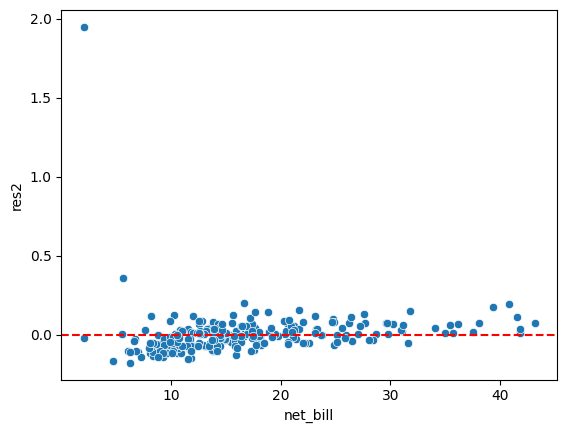

In [8]:
tips['res2'] = reg_log_net_bill.resid
sns.scatterplot(x = 'net_bill', y = 'res2', data = tips)
plt.axhline(y = 0, color = 'red', linestyle='--')

###  3. ajuste o modelo de ```tip_pct``` em função de um polinômio de segundo grau em ```net_bill```.

In [9]:
reg_poly_net_bill = smf.ols('tip_pct ~ net_bill + I(net_bill**2)', data = tips).fit()
reg_poly_net_bill.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                tip_pct   R-squared:                       0.158
Model:                            OLS   Adj. R-squared:                  0.151
Method:                 Least Squares   F-statistic:                     22.55
Date:                Thu, 25 Jun 2026   Prob (F-statistic):           1.06e-09
Time:                        18:47:32   Log-Likelihood:                 117.25
No. Observations:                 244   AIC:                            -228.5
Df Residuals:                     241   BIC:                            -218.0
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
====================================================================================
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
Intercept            0.4851      0.047     10.332      0.000       0.393       0.578
net_bill            -0.0268      0.005     -5.477      0.000      -0.036      -0.017
I(net_bill ** 2)     0.0005      0.000      4.356      0.000       0.000       0.001
==============================================================================
Omnibus:                      447.620   Durbin-Watson:                   2.026
Prob(Omnibus):                  0.000   Jarque-Bera (JB):           186035.672
Skew:                          10.140   Prob(JB):                         0.00
Kurtosis:                     136.744   Cond. No.                     2.42e+03
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 2.42e+03. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

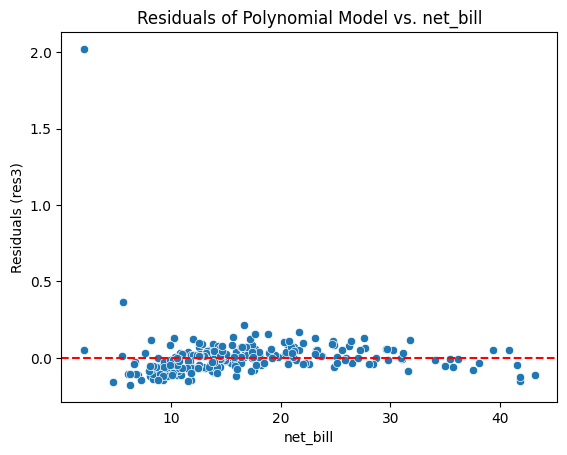

In [10]:
tips['res3'] = reg_poly_net_bill.resid
sns.scatterplot(x = 'net_bill', y = 'res3', data = tips)
plt.axhline(y = 0, color = 'red', linestyle='--')
plt.title('Residuals of Polynomial Model vs. net_bill')
plt.xlabel('net_bill')
plt.ylabel('Residuals (res3)')
plt.show()

###  4. ajuste um modelo no log do ```tip_pct``` em função de ```net_bill```. Calcule o $R^2$ também em ```tip_pct```

In [11]:
reg_log_tip_pct = smf.ols('np.log(tip_pct) ~ net_bill', data = tips).fit()
reg_log_tip_pct.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:        np.log(tip_pct)   R-squared:                       0.235
Model:                            OLS   Adj. R-squared:                  0.232
Method:                 Least Squares   F-statistic:                     74.48
Date:                Thu, 25 Jun 2026   Prob (F-statistic):           8.27e-16
Time:                        18:47:41   Log-Likelihood:                -106.00
No. Observations:                 244   AIC:                             216.0
Df Residuals:                     242   BIC:                             223.0
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -1.2749      0.056    -22.872      0.000      -1.385      -1.165
net_bill      -0.0259      0.003     -8.630      0.000      -0.032      -0.020
==============================================================================
Omnibus:                       49.929   Durbin-Watson:                   1.938
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              258.392
Skew:                           0.664   Prob(JB):                     7.78e-57
Kurtosis:                       7.864   Cond. No.                         43.3
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [12]:
# Calculate R-squared for tip_pct based on the log-transformed model
tips['pred_log_tip_pct'] = reg_log_tip_pct.predict(tips)
tips['pred_tip_pct'] = np.exp(tips['pred_log_tip_pct'])

# Calculate the total sum of squares (SST) for tip_pct
sst_tip_pct = np.sum((tips['tip_pct'] - tips['tip_pct'].mean())**2)

# Calculate the residual sum of squares (SSR) for tip_pct using the transformed predictions
ssr_tip_pct = np.sum((tips['tip_pct'] - tips['pred_tip_pct'])**2)

# Calculate the R-squared for tip_pct
r_squared_tip_pct = 1 - (ssr_tip_pct / sst_tip_pct)
print(f"R-squared for tip_pct (from log-transformed model): {r_squared_tip_pct:.3f}")

R-squared for tip_pct (from log-transformed model): 0.087


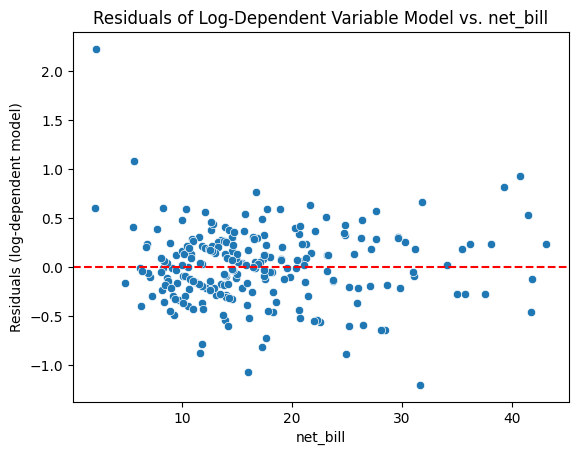

In [13]:
tips['res_log_tip_pct'] = reg_log_tip_pct.resid
sns.scatterplot(x = 'net_bill', y = 'res_log_tip_pct', data = tips)
plt.axhline(y = 0, color = 'red', linestyle='--')
plt.title('Residuals of Log-Dependent Variable Model vs. net_bill')
plt.xlabel('net_bill')
plt.ylabel('Residuals (log-dependent model)')
plt.show()

###  5. ajuste um modelo no log do ```tip_pct``` em função do log de ```net_bill```. Calcule o $R^2$ também em ```tip_pct```.

In [14]:
import statsmodels.formula.api as smf
reg_log_log_net_bill = smf.ols('np.log(tip_pct) ~ np.log(net_bill)', data = tips).fit()
reg_log_log_net_bill.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:        np.log(tip_pct)   R-squared:                       0.293
Model:                            OLS   Adj. R-squared:                  0.291
Method:                 Least Squares   F-statistic:                     100.5
Date:                Thu, 25 Jun 2026   Prob (F-statistic):           5.20e-20
Time:                        18:48:06   Log-Likelihood:                -96.357
No. Observations:                 244   AIC:                             196.7
Df Residuals:                     242   BIC:                             203.7
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
====================================================================================
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
Intercept           -0.3942      0.133     -2.961      0.003      -0.657      -0.132
np.log(net_bill)    -0.4849      0.048    -10.026      0.000      -0.580      -0.390
==============================================================================
Omnibus:                       12.633   Durbin-Watson:                   1.976
Prob(Omnibus):                  0.002   Jarque-Bera (JB):               28.054
Skew:                           0.141   Prob(JB):                     8.10e-07
Kurtosis:                       4.637   Cond. No.                         17.9
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [15]:
# Calculate R-squared for tip_pct based on the log-log model
tips['pred_log_log_tip_pct'] = reg_log_log_net_bill.predict(tips)
tips['pred_tip_pct_from_log_log'] = np.exp(tips['pred_log_log_tip_pct'])

# Calculate the total sum of squares (SST) for tip_pct
sst_tip_pct = np.sum((tips['tip_pct'] - tips['tip_pct'].mean())**2)

# Calculate the residual sum of squares (SSR) for tip_pct using the transformed predictions
ssr_tip_pct_log_log = np.sum((tips['tip_pct'] - tips['pred_tip_pct_from_log_log'])**2)

# Calculate the R-squared for tip_pct
r_squared_tip_pct_log_log = 1 - (ssr_tip_pct_log_log / sst_tip_pct)
print(f"R-squared for tip_pct (from log-log model): {r_squared_tip_pct_log_log:.3f}")

R-squared for tip_pct (from log-log model): 0.228


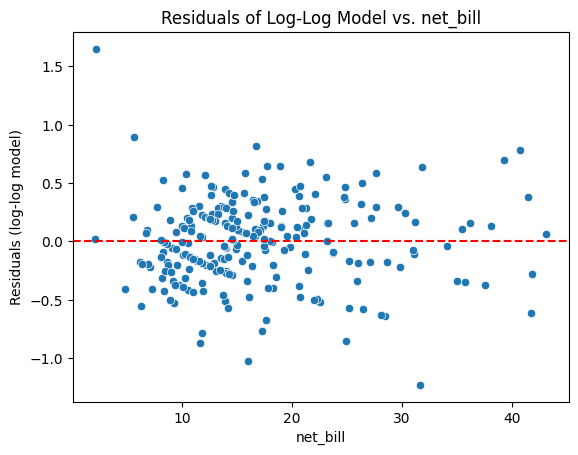

In [16]:
tips['res_log_log_net_bill'] = reg_log_log_net_bill.resid
sns.scatterplot(x = 'net_bill', y = 'res_log_log_net_bill', data = tips)
plt.axhline(y = 0, color = 'red', linestyle='--')
plt.title('Residuals of Log-Log Model vs. net_bill')
plt.xlabel('net_bill')
plt.ylabel('Residuals (log-log model)')
plt.show()

###  6. qual modelo resultou no melhor ajuste?

### Comparação do R2 para `tip_pct`:

1.  **Modelo 1 (`reg2`): `tip_pct ~ net_bill`**
    *   R2 para `tip_pct`: 0.091

2.  **Modelo 2 (`reg_log_net_bill`): `tip_pct ~ np.log(net_bill)`**
    *   R2 para `tip_pct`: 0.202

3.  **Modelo 3 (`reg_poly_net_bill`): `tip_pct ~ net_bill + I(net_bill**2)`**
    *   R2 para `tip_pct`: 0.158

4.  **Modelo 4 (`reg_log_tip_pct`): `np.log(tip_pct) ~ net_bill`**
    *   R2 para `tip_pct` (after back-transformation): 0.087

5.  **Modelo 5 (`reg_log_log_net_bill`): `np.log(tip_pct) ~ np.log(net_bill)`**
    *   R2 para `tip_pct` (after back-transformation): 0.228

Com base nesses valores, o modelo `np.log(tip_pct) ~ np.log(net_bill)` (`reg_log_log_net_bill`) resultou no R2 melhor ajustado para `tip_pct`.